In [1]:
import os
os.chdir("./..")

from PVDataset import PVDataset

ds = PVDataset(r"C:\Users\peter\Repos\ENFIELD-data\processed_unpack\nwp_0h", "Slovakia", "top", "train")

In [90]:
from models.ADRInspired import ADRInspired as ADR
from utils.config import load_config
import torch

config = load_config("./config/ADR.yaml")
model_fit = ADR(config)
model_fit.load_state_dict(torch.load(r"C:\Users\peter\Repos\ENFIELD-PIML\checkpoints\PV-PIML\fit_Slovakia\epoch=36-step=148.ckpt", weights_only=False)["state_dict"])

model_default = ADR(config)

In [97]:
for name, param in model_default.named_parameters():
    print(f"{name}: {param.detach().cpu().numpy():.3f}")

albedo: 0.250
u0: 25.000
u1: 7.000
k_a: 1.000
k_d: -6.000
tc_d: 0.000
k_rs: 0.001
k_rsh: 0.001


In [96]:
for name, param in model_fit.named_parameters():
    print(f"{name}: {param.detach().cpu().numpy():.3f}")

albedo: 0.554
u0: 26.279
u1: 6.367
k_a: 0.851
k_d: -7.159
tc_d: 0.092
k_rs: 0.382
k_rsh: 1.260


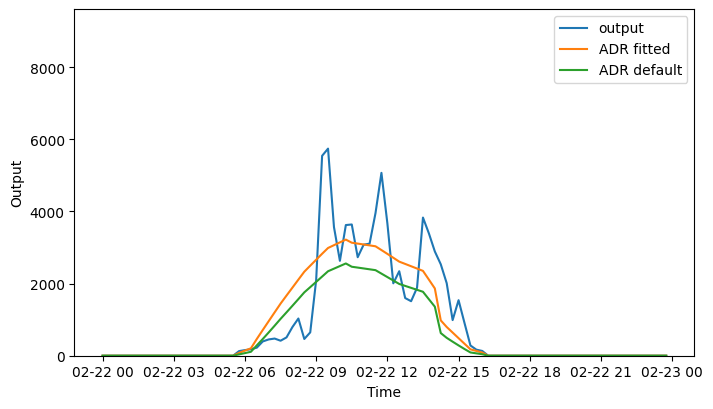

In [130]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

import random

x, y, metadata = ds[random.randint(0, len(ds)-1)]
metadata_tensors = {}
for k, v in metadata.items():
    try:
        metadata_tensors[k] = torch.tensor(v).unsqueeze(0)
    except (TypeError, ValueError):
        metadata_tensors[k] = [v]

y_hat = model_fit([t.unsqueeze(0) for t in x], metadata_tensors)
fitted_prediction = y_hat.detach().numpy()

y_hat = model_default([t.unsqueeze(0) for t in x], metadata_tensors)
default_prediction = y_hat.detach().numpy()

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.plot(pd.to_datetime(x[-1], unit="s"), y*4000, label="output")
ax.plot(pd.to_datetime(x[-1], unit="s"), fitted_prediction[0], label="ADR fitted")
ax.plot(pd.to_datetime(x[-1], unit="s"), default_prediction[0], label="ADR default")
ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend()
ax.set_ylim(0,9610)
plt.show()